# Bicycle production using a background database

Let's see how we would build a bicycle production foreground system on a background database. We can use the recently released [BAFU 2025 database](https://nexus.openlca.org/database/BAFU), which is freely available.

This is a bit challenging to import right now, so we have a prepared project with an _imperfect_ import already on the server.

This means we won't be woking in the `Bicycle example` anymore, and won't have any of our previously prepared databases.

We start by restoring the BAFU project:

In [36]:
import bw2io as bi

In [37]:
bi.restore_project_directory(
    "/etc/data/bafu-2025.tar.gz", 
    project_name="BAFU 2025", 
    overwrite_existing=True
)

Restoring project backup archive - this could take a few minutes...
Restored project: BAFU 2025


'BAFU 2025'

Just restoring the project doesn't activate it - this still needs to be done manually.

In [38]:
import bw2data as bd

In [39]:
bd.projects.set_current("BAFU 2025")

Check to make sure we have some databases:

In [40]:
bd.databases

Databases dictionary with 3 object(s):
	BAFU 2025
	BAFU-2025-biosphere
	ecoinvent-3.12-biosphere

This project uses the ecoinvent 3.12 set of biosphere flows, but doesn't have the ecoinvent database. It also has the 3.12 LCIA impact categories:

In [41]:
len(bd.methods)

633

In [43]:
len(bd.Database("ecoinvent-3.12-biosphere"))

9850

In [44]:
len(bd.Database("BAFU 2025"))

11747

In [45]:
bafu = bd.Database("BAFU 2025")

In [68]:
bafu.search("potato")

['Potato grading' (kilogram, CH, ['agricultural']),
 'Potato starch, at plant' (kilogram, DE, ['agricultural', 'plant production']),
 'Potato seed organic, at regional storehouse' (kilogram, CH, ['agricultural', 'plant production\\seeds']),
 'Potato seed IP, at regional storehouse' (kilogram, CH, ['agricultural', 'plant production\\seeds']),
 'Treatment, potato starch production effluent, to wastewater treatment, class 2' (cubic meter, CH, ['wastewater treatment']),
 'Potato seed IP, at farm' (kilogram, CH, ['agricultural', 'plant production\\seeds']),
 'Potato seed organic, at farm' (kilogram, CH, ['agricultural', 'plant production\\seeds']),
 'Potato haulm cutting' (hectare, CH, ['agricultural']),
 'Potato planting' (hectare, CH, ['agricultural']),
 'Potatoes, at farm' (kilogram, US, ['agricultural', 'plant production']),
 'Tillage, hoeing and earthing-up, potatoes' (hectare, CH, ['agricultural']),
 'Planting' (hectare, CH, ['agricultural']),
 'Harvesting, by complete harvester, pota

In [61]:
bd.get_node(name='Flax straw scutching, tows from scutching', database=bafu.name)["code"]

'76208a038606d2f8c15e87df7d1cc438'

In [63]:
bd.get_node(name='Flax straw scutching, tows from scutching', database=bafu.name).id

268887679958495232

In [64]:
bd.get_node(id=268887679958495232)

'Flax straw scutching, tows from scutching' (kilogram, FR, ['construction materials', 'flax insulation'])

In [65]:
scutching = bd.get_node(code='76208a038606d2f8c15e87df7d1cc438')

In [69]:
potato = bd.get_node(name='Potato seed IP, at regional storehouse')

In [66]:
for exc in scutching.edges():
    print(exc)

Exchange: 1.0 kilogram 'Flax straw scutching, tows from scutching' (kilogram, FR, ['construction materials', 'flax insulation']) to 'Flax straw scutching, tows from scutching' (kilogram, FR, ['construction materials', 'flax insulation'])
Exchange: 2.0856202e-09 kilogram 'Sulfide' (kilogram, None, ('water', 'ocean')) to 'Flax straw scutching, tows from scutching' (kilogram, FR, ['construction materials', 'flax insulation'])
Exchange: 0.00119403 kilo Becquerel 'Radium-228' (kilo Becquerel, None, ('water', 'surface water')) to 'Flax straw scutching, tows from scutching' (kilogram, FR, ['construction materials', 'flax insulation'])
Exchange: 8.6436915e-09 kilogram 'Potassium I' (kilogram, None, ('soil',)) to 'Flax straw scutching, tows from scutching' (kilogram, FR, ['construction materials', 'flax insulation'])
Exchange: 1.1984405e-07 kilo Becquerel 'Radon-220' (kilo Becquerel, None, ('air', 'urban air close to ground')) to 'Flax straw scutching, tows from scutching' (kilogram, FR, ['cons

- `production()`
- `consumers()`
- `technosphere()`

In [75]:
for exc in potato.technosphere():
    print(exc)

Exchange: 5e-05 kilogram 'Nitrile-compounds, at regional storehouse' (kilogram, CH, ['chemicals', 'pesticides']) to 'Potato seed IP, at regional storehouse' (kilogram, CH, ['agricultural', 'plant production\\seeds'])
Exchange: 4e-05 cubic meter 'Building, multi-storey' (cubic meter, RER, ['construction', 'others\\infrastructure']) to 'Potato seed IP, at regional storehouse' (kilogram, CH, ['agricultural', 'plant production\\seeds'])
Exchange: 0.073 kilowatt hour 'Electricity, low voltage, at grid' (kilowatt hour, CH, ['electricity', 'supply mix']) to 'Potato seed IP, at regional storehouse' (kilogram, CH, ['agricultural', 'plant production\\seeds'])
Exchange: 0.12 ton kilometer 'Transport, freight, lorry, 16t-32t gross weight, fleet average' (ton kilometer, CH, ['transport systems', 'road\\Transformation']) to 'Potato seed IP, at regional storehouse' (kilogram, CH, ['agricultural', 'plant production\\seeds'])
Exchange: 1.0 kilogram 'Potato seed IP, at farm' (kilogram, CH, ['agricultura

In [74]:
potato["type"]

'processwithreferenceproduct'

## Exploring the existing bicycle production

This BAFU database has electric and normal bicycles:

In [ ]:
db = bd.Database("BAFU 2025")

In [76]:
db.search("bicycle")

['Maintenance, electric bicycle, without battery' (unit, CH, ['transport systems', 'road\\Vehicle components\\Energy storage\\Lithium-ion battery']),
 'Maintenance, electric bicycle' (unit, CH, ['transport systems', 'road\\operations\\infrastructure']),
 'Maintenance, bicycle' (unit, CH, ['transport systems', 'road\\operations\\infrastructure']),
 'Electric bicycle production, without battery and motor' (unit, RER, ['transport systems', 'road\\Vehicle components\\Energy storage\\Lithium-ion battery']),
 'Maintenance, electric bicycle, LiNCM battery' (unit, CH, ['transport systems', 'road\\operations\\infrastructure']),
 'Operation, electric bicycle' (kilometer, CH, ['transport systems', 'road\\operations']),
 'Operation, electric bicycle, certified electricity' (kilometer, CH, ['transport systems', 'road\\operations']),
 'Disposal, bicycle' (unit, CH, ['transport waste']),
 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 'Disposal

Let's look at the bill of materials for a bicycle:

In [77]:
bicycle = bd.get_node(name='Bicycle, at regional storage')

In [78]:
list(bicycle.technosphere())

[Exchange: 0.000744 cubic meter 'Treatment, sewage, to wastewater treatment, class 3' (cubic meter, CH, ['wastewater treatment']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 0.03 kilogram 'Polyurethane, flexible foam, at plant' (kilogram, RER, ['plastics', 'thermosets']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 7.5325 kilogram 'Aluminium, production mix, at plant' (kilogram, RER, ['metals', 'extraction']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 1.9575 kilogram 'Polyethylene, HDPE, granulate, at plant' (kilogram, RER, ['plastics', 'thermoplasts']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 0.3375 kilogram 'Wire drawing, steel' (kilogram, RER, ['metals', 'chipless shaping']) to 'Bicycle, at re

We can also filter the BOM to look at metals:

In [79]:
[
    exc
    for exc in bicycle.technosphere()
    if (
        ("steel" in exc.input["name"].lower()) 
        or ("aluminium" in exc.input["name"].lower())
        or ("aluminum" in exc.input["name"].lower())
    )
]

[Exchange: 7.5325 kilogram 'Aluminium, production mix, at plant' (kilogram, RER, ['metals', 'extraction']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 0.3375 kilogram 'Wire drawing, steel' (kilogram, RER, ['metals', 'chipless shaping']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 0.75 meter 'Welding, arc, aluminium' (meter, RER, ['metals', 'welding']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 0.159 kilogram 'Turning, chromium steel, conventional, average' (kilogram, RER, ['metals', 'chipping']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 1.59 kilogram 'Chromium steel 18/8, at plant' (kilogram, RER, ['metals', 'ferro']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\oper

OK - let's only change the amount of metals used. This is way to heavy for the bicycle we want.

## Modification option 1: Via `.copy()` 

There are several ways to make such changes. One thing we could do is to copy the bicycle to a new database, and then change the copied exchange amounts.

In [80]:
database_with_copy = bd.Database("With copy of bicycle")
database_with_copy.register()

This part is a little tricky - the `database` is the string _label_ of the new database.

In [82]:
bicycle_copy = bicycle.copy(database=database_with_copy.name)

In [83]:
bicycle_copy['database']

'With copy of bicycle'

This has copied over our exchanges:

In [84]:
len(bicycle_copy.exchanges())

23

Let's reduce the amount of metals. We can create a filter function for exchanges to get only metal-related ones:

In [86]:
def is_metals_edge(edge):
    return (
        ("steel" in edge.input["name"].lower()) 
        or ("aluminium" in edge.input["name"].lower())
        or ("aluminum" in edge.input["name"].lower())
    )

In [88]:
for edge in bicycle_copy.edges():
    print(is_metals_edge(edge))

False
False
False
True
False
True
False
False
False
False
True
False
False
False
True
True
False
True
True
False
False
True
False


And then loop over the exchanges. We can reduced the metals amount by 80%.

In [89]:
for edge in bicycle_copy.technosphere():
    if is_metals_exchange(edge):
        old_amount = edge["amount"]
        new_amount = old_amount * 0.2
        edge["amount"] = new_amount
        edge.save()
        print(f"Changed amount from {old_amount} to {new_amount} in edge {edge}")

Changed amount from 7.5325 to 1.5065 in edge Exchange: 1.5065 kilogram 'Aluminium, production mix, at plant' (kilogram, RER, ['metals', 'extraction']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])
Changed amount from 0.3375 to 0.0675 in edge Exchange: 0.0675 kilogram 'Wire drawing, steel' (kilogram, RER, ['metals', 'chipless shaping']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])
Changed amount from 0.75 to 0.15000000000000002 in edge Exchange: 0.15000000000000002 meter 'Welding, arc, aluminium' (meter, RER, ['metals', 'welding']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])
Changed amount from 0.159 to 0.0318 in edge Exchange: 0.0318 kilogram 'Turning, chromium steel, conventional, average' (kilogram, RER, ['metals', 'chipping']) to 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\opera

## Modification option 2: Via `.new_node()`

We can also create a new node from a fresh start.

In [90]:
clean_database = bd.Database("New database")
clean_database.register()

In [91]:
new_bicycle = clean_database.new_node(
    name="bicycle",
    unit="number",
    location="Paris"
)

We can then add some edges to this clean bicycle. This can be completely from our own research, but we can also pull some edges from the existing bicycle definition:

In [92]:
import random

In [93]:
for other_exc in bicycle_copy.technosphere():
    if random.random() < 0.4:
        new_bicycle.new_exchange(
            amount=other_exc["amount"],
            input=other_exc.input,
            type=other_exc["type"],
        ).save()

In [95]:
len(bicycle_copy.edges()), len(new_bicycle.edges())

(23, 8)

# Exercise

Make a copy of a BAFU electric bicycle, and reduce the total amount of steel used to 2.5 kilograms.

In [98]:
eb = bd.get_node(name='Electric bicycle, at regional storage')

In [109]:
sorted([
    edge.input["name"]
    for edge in eb.edges()
])

['Aluminium, production mix, at plant',
 'Battery, LiIo, rechargeable, prismatic, at plant',
 'Chromium steel 18/8, at plant',
 'Disposal, municipal solid waste, 22.9% water, to municipal incineration',
 'Electric bicycle, at regional storage',
 'Electric motor, electric vehicle, at plant',
 'Electricity, medium voltage, at grid',
 'Heat, waste',
 'Injection moulding',
 'Light fuel oil, burned in industrial furnace 1MW, non-modulating',
 'Natural gas, burned in industrial furnace 1MWth',
 'Polyethylene, HDPE, granulate, at plant',
 'Polyurethane, flexible foam, at plant',
 'Powder coating, aluminium sheet',
 'Road vehicle plant',
 'Section bar extrusion, aluminium',
 'Steel, low-alloyed, at plant',
 'Synthetic rubber, at plant',
 'Tap water, at user',
 'Transport, freight, lorry, fleet average',
 'Transport, transoceanic freight ship',
 'Treatment, sewage, to wastewater treatment, class 3',
 'Turning, chromium steel, conventional, average',
 'Welding, arc, aluminium',
 'Wire drawing, s

In [102]:
STEEL = [
    'Chromium steel 18/8, at plant',
    'Steel, low-alloyed, at plant',
]

In [103]:
steel_edges = [edge for edge in eb.edges() if edge.input["name"] in STEEL]

In [110]:
steel_edges

[Exchange: 1.59 kilogram 'Chromium steel 18/8, at plant' (kilogram, RER, ['metals', 'ferro']) to 'Electric bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure']),
 Exchange: 4.9025 kilogram 'Steel, low-alloyed, at plant' (kilogram, RER, ['metals', 'ferro']) to 'Electric bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])]

In [106]:
total_steel = sum(edge["amount"] for edge in steel_edges)
coefficient = 2.5 / total_steel
coefficient

0.3850596842510589

In [ ]:
for edge in steel_edges:
    edge["amount"] = edge["amount"] * coefficient
    edge.save()

In [111]:
for edge in eb.edges():
    if "steel" in edge.input["name"].lower() and edge not in steel_edges:
        edge["amount"] = edge["amount"] * coefficient
        edge.save()

Exchange: 0.159 kilogram 'Turning, chromium steel, conventional, average' (kilogram, RER, ['metals', 'chipping']) to 'Electric bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])
Exchange: 0.3375 kilogram 'Wire drawing, steel' (kilogram, RER, ['metals', 'chipless shaping']) to 'Electric bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])


In [113]:
bicycle_copy.exchanges?

Signature:
bicycle_copy.exchanges(
    exchanges_class=<class 'bw2data.backends.proxies.Exchanges'>,
)
Docstring: <no docstring>
File:      /opt/tljh/user/envs/bw25/lib/python3.12/site-packages/bw2data/backends/proxies.py
Type:      method

In [117]:
bd.databases

Databases dictionary with 5 object(s):
	BAFU 2025
	BAFU-2025-biosphere
	New database
	With copy of bicycle
	ecoinvent-3.12-biosphere

In [119]:
bd.Database("ecoinvent-3.12-biosphere").search("carbon dioxide")

['Carbon dioxide, fossil' (kilogram, None, ('air',)),
 'Carbon dioxide, non-fossil' (kilogram, None, ('air',)),
 'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil',)),
 'Carbon dioxide, from soil or biomass stock' (kilogram, None, ('air',)),
 'Carbon dioxide, in air' (kilogram, None, ('natural resource', 'in air')),
 'Carbon dioxide, fossil' (kilogram, None, ('air', 'lower stratosphere + upper troposphere')),
 'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil', 'industrial')),
 'Carbon dioxide, fossil' (kilogram, None, ('air', 'urban air close to ground')),
 'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil', 'agricultural')),
 'Carbon dioxide, fossil' (kilogram, None, ('air', 'low population density, long-term')),
 'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil', 'forestry')),
 'Carbon dioxide, non-fossil' (kilogram, None, ('air', 'low population density, long-term')),
 'Carbon dioxide, non-fossil, resource correct

In [127]:
co2 = {
    flow.id
    for flow in bd.Database("ecoinvent-3.12-biosphere") 
    if flow['name'] == 'Carbon dioxide, fossil'
}
co2

{268857892854542374,
 268857892896485458,
 268857893106200651,
 268857893244612729,
 268857893378830355}

In [123]:
example_method = sorted(bd.methods)[0]

In [128]:
climate_change_categories = []

In [130]:
from tqdm import tqdm

In [131]:
for category in tqdm(bd.methods):
    flows = {
        node_id
        for node_id, _ in bd.Method(category).load()
    }
    if flows.intersection(co2):
        climate_change_categories.append(category)

print(len(climate_change_categories))

100%|██████████| 633/633 [00:00<00:00, 4223.88it/s]

97


In [132]:
sorted(climate_change_categories)

[('ecoinvent-3.12',
  'CML v4.8 2016',
  'climate change',
  'global warming potential (GWP100)'),
 ('ecoinvent-3.12',
  'CML v4.8 2016 no LT',
  'climate change no LT',
  'global warming potential (GWP100) no LT'),
 ('ecoinvent-3.12',
  'EF v3.0',
  'climate change',
  'global warming potential (GWP100)'),
 ('ecoinvent-3.12',
  'EF v3.0',
  'climate change: fossil',
  'global warming potential (GWP100)'),
 ('ecoinvent-3.12',
  'EF v3.0 no LT',
  'climate change no LT',
  'global warming potential (GWP100) no LT'),
 ('ecoinvent-3.12',
  'EF v3.0 no LT',
  'climate change: fossil no LT',
  'global warming potential (GWP100) no LT'),
 ('ecoinvent-3.12',
  'EF v3.1',
  'climate change',
  'global warming potential (GWP100)'),
 ('ecoinvent-3.12',
  'EF v3.1',
  'climate change: fossil',
  'global warming potential (GWP100)'),
 ('ecoinvent-3.12',
  'EF v3.1 no LT',
  'climate change no LT',
  'global warming potential (GWP100) no LT'),
 ('ecoinvent-3.12',
  'EF v3.1 no LT',
  'climate chang

In [126]:
{
    node_id
    for node_id, _ in bd.Method(example_method).load()
}

{268857892808405104,
 268857892816793649,
 268857892841959443,
 268857892959399965,
 268857893022314538,
 268857893030703136,
 268857893030703218,
 268857893043286052,
 268857893106200607,
 268857893118783563,
 268857893156532225,
 268857893156532277,
 268857893198475319,
 268857893211058190,
 268857893223641140,
 268857893315915866,
 268857893336887361,
 268857893391413308,
 268857893445939212,
 268857893454327924,
 268857893508853817,
 268857893517242484,
 268857893529825392}

In [133]:
cc_impact_category = (
    'ecoinvent-3.12',
    'IPCC 2021',
    'climate change: fossil',
    'global warming potential (GWP100)'
)

In [134]:
bicycle, bicycle_copy

'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])

In [135]:
import bw2calc as bc

In [136]:
functional_unit, data_objs, _ = bd.prepare_lca_inputs({bicycle: 1, bicycle_copy: 1}, method=cc_impact_category)

In [144]:
from time import time

In [148]:
start = time()

lca = bc.LCA({bicycle.id: 1}, data_objs=data_objs)
lca.lci()
lca.lcia()
lca.score

print(time() - start)

0.11306643486022949


In [146]:
start = time()

lca.lcia({bicycle_copy.id: 1})
lca.score

print(time() - start)

0.00625920295715332


In [174]:
len(bd.Database("ecoinvent-3.12-biosphere"))

9850

In [172]:
lca.biosphere_matrix.shape

(2139, 11748)

In [154]:
df = lca.to_dataframe(cutoff=10)
df

,row_index,col_index,amount,row_id,col_id,row_database,row_code,row_name,row_location,row_unit,row_type,row_categories,row_product,col_database,col_code,col_name,col_location,col_unit,col_type,col_reference_product
0,1382,434,6.703260,268857893378830355,268887491084791808,ecoinvent-3.12-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,BAFU 2025,8f03d251cd09068e905c684be36b2b8f,"Natural gas, burned in industrial furnace 1MWth",CH,megajoule,processwithreferenceproduct,"Natural gas, burned in industrial furnace 1MWt..."
1,1117,2711,6.314119,268857893244612729,268887530045681664,ecoinvent-3.12-biosphere,349b29d1-3e58-4c66-98b9-9d1a076efd2e,"Carbon dioxide, fossil",None,kilogram,emission,air,None,BAFU 2025,a11dda77bf028b58965acb6ba1c7e41a,"Aluminium, primary, liquid, at plant",RER,kilogram,processwithreferenceproduct,"Aluminium, primary, liquid, at plant {RER}"
2,1382,4504,4.247869,268857893378830355,268887560609574912,ecoinvent-3.12-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,BAFU 2025,e1fa442f3c7278ee8bc8316cfe4f39f8,"Hard coal, burned in power plant",PL,megajoule,processwithreferenceproduct,"Hard coal, burned in power plant {PL}"
3,1382,8482,4.129003,268857893378830355,268887630188883968,ecoinvent-3.12-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,BAFU 2025,515fabc778e80b9f60c899c7fed644bb,"Hard coal, burned in power plant",CN,megajoule,processwithreferenceproduct,"Hard coal, burned in power plant {CN}"
4,1382,10785,3.990021,268857893378830355,268887669866999808,ecoinvent-3.12-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,BAFU 2025,4774842c8173c1d08696341121f1b923,"Heavy fuel oil, burned in industrial furnace 1...",RER,megajoule,processwithreferenceproduct,"Heavy fuel oil, burned in industrial furnace 1..."
5,1117,3678,3.604403,268857893244612729,268887544570556416,ecoinvent-3.12-biosphere,349b29d1-3e58-4c66-98b9-9d1a076efd2e,"Carbon dioxide, fossil",None,kilogram,emission,air,None,BAFU 2025,0d08b86905be2a1ed1b010475bace84d,"Polyethylene, HDPE, granulate, at plant",RER,kilogram,processwithreferenceproduct,"Polyethylene, HDPE, granulate, at plant {RER}"
6,1117,2772,3.367023,268857893244612729,268887530746130432,ecoinvent-3.12-biosphere,349b29d1-3e58-4c66-98b9-9d1a076efd2e,"Carbon dioxide, fossil",None,kilogram,emission,air,None,BAFU 2025,c793e4b8ff7844a0198dc13dd36bf55e,"Pig iron, at plant",RER,kilogram,processwithreferenceproduct,"Pig iron, at plant {RER}"
7,1382,2253,3.288289,268857893378830355,268887521069871104,ecoinvent-3.12-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,BAFU 2025,e172673b0d1e58815fa5d6acc64ad547,"Hard coal, burned in industrial furnace 1-10MW",RER,megajoule,processwithreferenceproduct,"Hard coal, burned in industrial furnace 1-10MW..."
8,1382,10768,3.008034,268857893378830355,268887669569204224,ecoinvent-3.12-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,BAFU 2025,8199122d7020bc1682da12def05eccab,"Hard coal, burned in power plant",DE,megajoule,processwithreferenceproduct,"Hard coal, burned in power plant {DE}"
9,1382,4277,2.930814,268857893378830355,268887555228282880,ecoinvent-3.12-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,BAFU 2025,21fd3e2b18cb7f0786c443eb567edb5d,"Natural gas, burned in power plant or heat plant",IT,megajoule,processwithreferenceproduct,"Natural gas, burned in power plant or heat pla..."


In [155]:
from bw2analyzer.matrix_grapher import SparseMatrixGrapher 

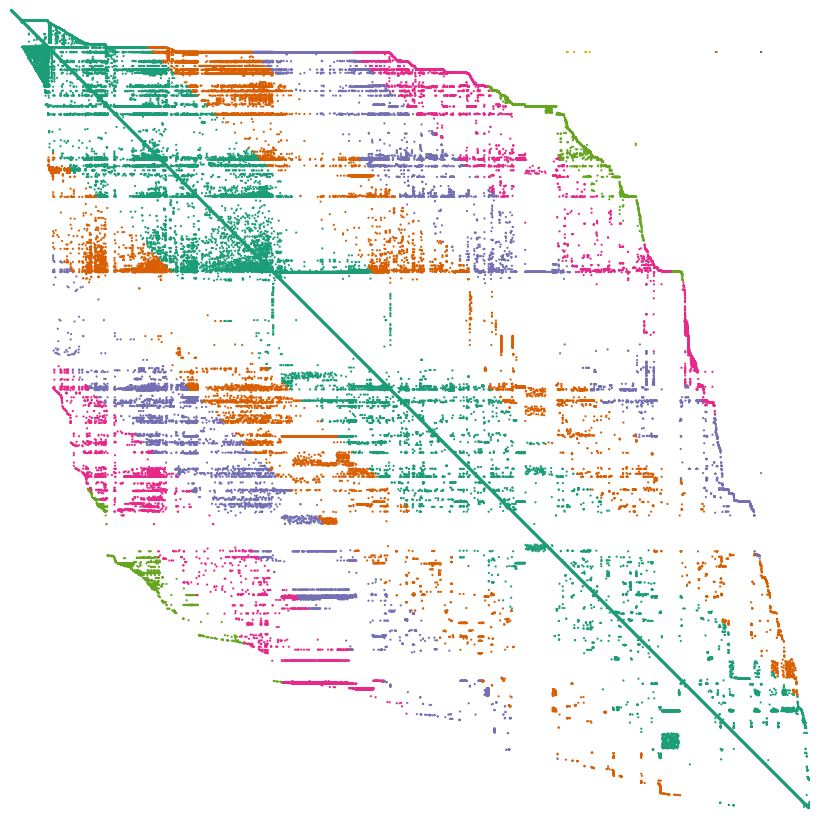

In [156]:
smg = SparseMatrixGrapher(lca.technosphere_matrix).ordered_graph(width=8, height=8)

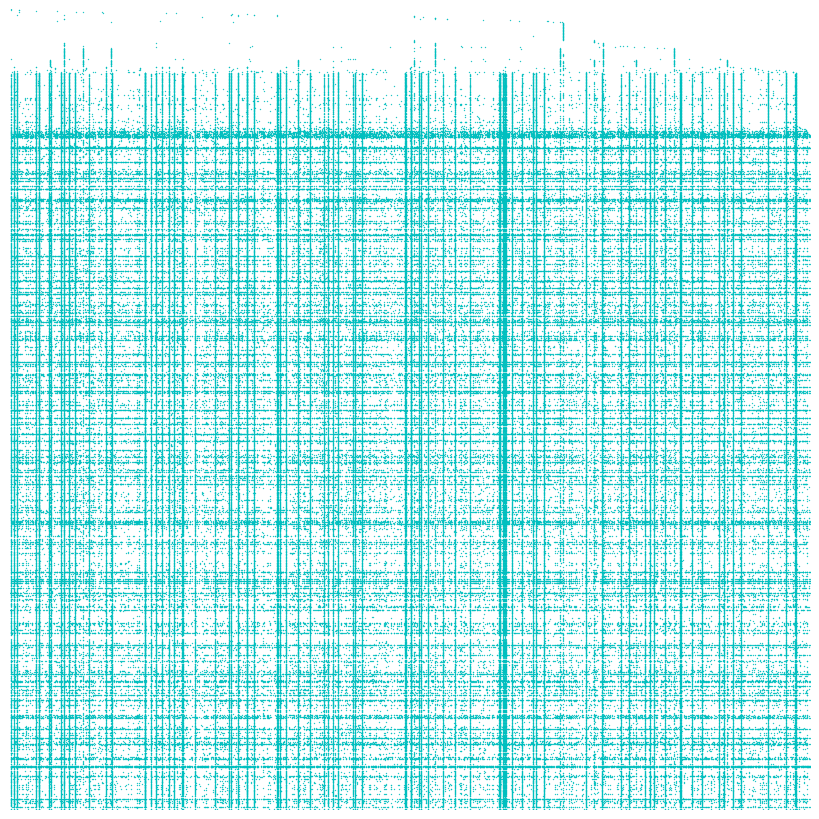

In [157]:
smg = SparseMatrixGrapher(lca.biosphere_matrix).graph(width=8, height=8)

In [159]:
from tqdm import tqdm

In [160]:
from collections import defaultdict

In [161]:
flow_count = defaultdict(int)

In [164]:
flow_count["foo"]

0

In [165]:
for node in tqdm(bafu):
    for edge in node.biosphere():
        flow_count[edge.input] += 1

100%|██████████| 11747/11747 [00:53<00:00, 217.82it/s]


In [167]:
sorted(
    [(count, node) for node, count in flow_count.items()],
    reverse=True
)

[(3433, 'Water' (cubic meter, None, ('water',))),
 (2495,
  'Water, unspecified natural origin' (cubic meter, None, ('natural resource', 'in water'))),
 (2450,
  'Methane, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))),
 (2224,
  'NMVOC, non-methane volatile organic compounds' (kilogram, None, ('air', 'non-urban air or from high stacks'))),
 (2046, 'Heat, waste' (megajoule, None, ('air', 'urban air close to ground'))),
 (1777,
  'Nitrogen oxides' (kilogram, None, ('air', 'non-urban air or from high stacks'))),
 (1770,
  'Ethane' (kilogram, None, ('air', 'non-urban air or from high stacks'))),
 (1769,
  'Propane' (kilogram, None, ('air', 'non-urban air or from high stacks'))),
 (1758,
  'Butane' (kilogram, None, ('air', 'non-urban air or from high stacks'))),
 (1741,
  'Mercury II' (kilogram, None, ('air', 'non-urban air or from high stacks'))),
 (1710, 'Heat, waste' (megajoule, None, ('air',))),
 (1565,
  'Nitrogen oxides' (kilogram, None, ('air', 'urban air cl

In [169]:
from bw2analyzer.econ import gini_coefficient, herfindahl_index, concentration_ratio, theil_index

In [170]:
income = lca.characterized_inventory.data

In [171]:
gini_coefficient(income), herfindahl_index(income), concentration_ratio(income), theil_index(income)

(0.9988966148488667,
 0.035203430214732254,
 0.2684889992309727,
 4.9635583541217425)

In [178]:
import bw2analyzer as ba

In [181]:
ba.print_recursive_supply_chain(bicycle_copy, max_level=1)

1: 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])
  0.000744: 'Treatment, sewage, to wastewater treatment, class 3' (cubic meter, CH, ['wastewater treatment'])
  0.03: 'Polyurethane, flexible foam, at plant' (kilogram, RER, ['plastics', 'thermosets'])
  1.51: 'Aluminium, production mix, at plant' (kilogram, RER, ['metals', 'extraction'])
  1.96: 'Polyethylene, HDPE, granulate, at plant' (kilogram, RER, ['plastics', 'thermoplasts'])
  0.0675: 'Wire drawing, steel' (kilogram, RER, ['metals', 'chipless shaping'])
  6.89: 'Electricity, medium voltage, at grid' (kilowatt hour, CN, ['electricity', 'supply mix'])
  1.96: 'Injection moulding' (kilogram, RER, ['plastics'])
  17: 'Transport, freight, lorry, fleet average' (ton kilometer, RER, ['transport systems', 'road\\Transformation'])
  221: 'Transport, transoceanic freight ship' (ton kilometer, OCE, ['transport systems', 'ship'])
  0.15: 'Welding, arc, aluminium' (meter, RER, ['metals',

In [183]:
ba.print_recursive_calculation(bicycle_copy, cc_impact_category)

Fraction of score | Absolute score | Amount | Activity
0001 | 33.07 |     1 | 'Bicycle, at regional storage' (unit, RER, ['transport systems', 'road\\operations\\infrastructure'])
  0.217 | 7.165 | 1.506 | 'Aluminium, production mix, at plant' (kilogram, RER, ['metals', 'extraction'])
    0.206 | 6.822 | 0.7717 | 'Aluminium, primary, at plant' (kilogram, RER, ['metals', 'extraction'])
      0.205 | 6.777 | 0.7864 | 'Aluminium, primary, liquid, at plant' (kilogram, RER, ['metals', 'extraction'])
  0.134 | 4.442 | 1.958 | 'Polyethylene, HDPE, granulate, at plant' (kilogram, RER, ['plastics', 'thermoplasts'])
  0.149 | 4.916 |  6.89 | 'Electricity, medium voltage, at grid' (kilowatt hour, CN, ['electricity', 'supply mix'])
    0.148 | 4.894 | 6.923 | 'Electricity, high voltage, at grid' (kilowatt hour, CN, ['electricity', 'supply mix'])
      0.147 | 4.877 | 7.018 | 'Electricity mix' (kilowatt hour, CN, ['electricity', 'supply mix'])
  0.0598 | 1.976 | 1.958 | 'Injection moulding' (kilogr